# 07 - Comparaison des stratégies (Backtest Final)

**Objectif** : Backtester DeepPilot vs les benchmarks classiques.

**Stratégies comparées** :
- Buy & Hold SPY
- 60/40 (SPY/TLT)
- Equal Weight (8 ETF)
- **DeepPilot** (HMM + RF + Markowitz)

**Métriques** :
- CAGR (rendement annualisé)
- Sharpe Ratio
- Max Drawdown
- Volatilité
- Calmar Ratio

**Période** : 2013-2024 (après 3 ans de training)

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Modules ML DeepPilot
from ml.config import ETF_TICKERS, REGIME_NAMES
from ml.portfolio.deeppilot_strategy import DeepPilotStrategy
from ml.portfolio.backtester import Backtester, run_full_backtest
from ml.portfolio.benchmarks import (
    calculate_benchmark_returns,
    calculate_benchmark_metrics,
    calculate_cumulative_returns,
    calculate_drawdown,
)

# Database
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Imports OK")

Imports OK


## 1. Chargement des données

In [2]:
# Connexion DB
DATABASE_URL = os.getenv("SUPABASE_DB_URL")
engine = create_engine(DATABASE_URL)

# Charger prix ETF
query_prices = """
SELECT date, ticker, close
FROM price
WHERE ticker IN ('SPY', 'TLT', 'GLD', 'VNQ', 'EFA', 'EEM', 'HYG', 'SH')
ORDER BY date, ticker
"""
df_prices_long = pd.read_sql(query_prices, engine, parse_dates=['date'])
df_prices = df_prices_long.pivot(index='date', columns='ticker', values='close')

# Charger macro
query_macro = """
SELECT date, vix, credit_spread_hy, yield_curve_10y2y, t10y as treasury_10y
FROM macro_indicator
ORDER BY date
"""
df_macro = pd.read_sql(query_macro, engine, parse_dates=['date'])
df_macro = df_macro.set_index('date')

# Remplir les valeurs manquantes de credit_spread_hy
# Utiliser la moyenne historique (environ 4-5% typiquement)
if df_macro['credit_spread_hy'].isna().any():
    # Forward fill puis backward fill pour les valeurs existantes
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].ffill().bfill()
    # Si encore des NaN, utiliser une valeur par défaut (moyenne historique ~4.5)
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].fillna(4.5)
    print("[INFO] credit_spread_hy: valeurs manquantes remplies")

print(f"Prix ETF : {df_prices.shape[0]} jours")
print(f"Macro : {df_macro.shape[0]} jours")
print(f"Macro NaN restants : {df_macro.isna().sum().sum()}")
print(f"Période : {df_prices.index.min().date()} à {df_prices.index.max().date()}")

[INFO] credit_spread_hy: valeurs manquantes remplies
Prix ETF : 4109 jours
Macro : 4326 jours
Macro NaN restants : 3
Période : 2010-01-04 à 2026-05-05


In [3]:
# Calculer les returns
df_returns = df_prices.pct_change().dropna()

print(f"Returns : {df_returns.shape[0]} jours")
print(f"ETF disponibles : {list(df_returns.columns)}")

Returns : 4108 jours
ETF disponibles : ['EEM', 'EFA', 'GLD', 'HYG', 'SH', 'SPY', 'TLT', 'VNQ']


## 2. Benchmarks

In [4]:
# Période de backtest
START_DATE = '2013-01-01'
END_DATE = '2024-12-31'

# Filtrer les données pour la période
df_returns_bt = df_returns.loc[START_DATE:END_DATE]

print(f"Période backtest : {df_returns_bt.index.min().date()} à {df_returns_bt.index.max().date()}")
print(f"Nombre de jours : {len(df_returns_bt)}")

Période backtest : 2013-01-02 à 2024-12-31
Nombre de jours : 3020


In [5]:
# Calculer les returns des benchmarks
benchmark_returns = calculate_benchmark_returns(
    df_returns_bt, 
    include_benchmarks=['spy', '6040', 'equal_weight']
)

print("Benchmarks calculés :")
for col in benchmark_returns.columns:
    print(f"  - {col}")

Benchmarks calculés :
  - SPY (Buy & Hold)
  - 60/40 (SPY/TLT)
  - Equal Weight


In [6]:
# Métriques des benchmarks
benchmark_metrics = calculate_benchmark_metrics(benchmark_returns, risk_free_rate=0.03)

print("\nMétriques des benchmarks :")
benchmark_metrics


Métriques des benchmarks :


,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar
benchmark,,,,,,,
SPY (Buy & Hold),409.50,14.55,16.71,0.691,0.836,-33.72,0.432
60/40 (SPY/TLT),188.10,9.23,10.46,0.595,0.756,-27.24,0.339
Equal Weight,52.97,3.61,7.75,0.079,0.100,-18.78,0.192


## 3. Backtest DeepPilot

In [7]:
# Créer la stratégie DeepPilot
print("Création de la stratégie DeepPilot...")
strategy = DeepPilotStrategy(
    risk_free_rate=0.03,
    min_weight=0.05,
    max_weight=0.25,
    regime_adjustment=True,
)

print(strategy.get_model_summary())

Création de la stratégie DeepPilot...
{'is_fitted': False, 'tickers': [], 'n_prediction_models': 0, 'regime_model': None, 'prediction_model': None, 'optimizer': 'Markowitz (max Sharpe)', 'constraints': {'min_weight': 0.05, 'max_weight': 0.25}}


In [8]:
# Créer le backtester
backtester = Backtester(
    transaction_cost=0.001,  # 0.1% par trade
    rebalance_freq='M',       # Mensuel
    risk_free_rate=0.03,
)

print("Backtester créé")
print(f"  - Frais : 0.1% par trade")
print(f"  - Rebalancement : Mensuel")

Backtester créé
  - Frais : 0.1% par trade
  - Rebalancement : Mensuel


In [9]:
# Debug pas à pas
from ml.features.feature_engineering import prepare_regime_features
from ml.models.regime_hmm import RegimeHMM

# Simuler le training initial
train_start = pd.Timestamp('2010-01-01')
start = pd.Timestamp('2013-01-01')

train_prices = df_prices.loc[train_start:start]
train_macro = df_macro.loc[train_start:start]

print(f"train_prices: {train_prices.shape}")
print(f"train_macro: {train_macro.shape}")
print(f"train_macro NaN: {train_macro.isna().sum().sum()}")

# Combiner
df_combined = pd.concat([train_prices, train_macro], axis=1).dropna()
print(f"\ndf_combined après dropna: {df_combined.shape}")
print(f"Période: {df_combined.index.min()} à {df_combined.index.max()}")

# Préparer features
print("\nPréparation des features de régime...")
X_regime = prepare_regime_features(df_combined)
print(f"X_regime shape: {X_regime.shape}")
print(f"X_regime NaN: {X_regime.isna().sum().sum()}")
print(f"X_regime colonnes: {list(X_regime.columns)}")

if len(X_regime) > 0:
    print(X_regime.describe())
else:
    print("ERREUR: X_regime est vide!")

train_prices: (754, 8)
train_macro: (793, 4)
train_macro NaN: 3

df_combined après dropna: (754, 12)
Période: 2010-01-04 00:00:00 à 2012-12-31 00:00:00

Préparation des features de régime...
X_regime shape: (754, 5)
X_regime NaN: 0
X_regime colonnes: ['vix_zscore', 'credit_spread_zscore', 'yield_curve_10y2y', 'spy_return_20d', 'spy_volatility_20d']
       vix_zscore  credit_spread_zscore  yield_curve_10y2y  spy_return_20d  \
count  754.000000            754.000000         754.000000      754.000000   
mean    -0.128059              0.066718           2.121989        0.008150   
std      1.284560              1.422466           0.530287        0.043277   
min     -2.419004             -3.095291           1.210000       -0.163025   
25%     -1.113783             -1.120869           1.670000       -0.020019   
50%     -0.458767              0.099297           2.125000        0.016306   
75%      0.630298              1.075142           2.660000        0.037988   
max      5.671761        

In [10]:
# Lancer le backtest
print("\n" + "="*60)
print("BACKTEST DEEPPILOT")
print("="*60)
print(f"Période : {START_DATE} à {END_DATE}")
print(f"Training initial : 3 ans avant {START_DATE}")
print(f"Réentraînement : Annuel")
print("\nCela peut prendre quelques minutes...\n")

result = backtester.run(
    strategy,
    df_prices,
    df_macro,
    start_date=START_DATE,
    end_date=END_DATE,
    train_years=3,
    retrain_freq='Y',
)

print("\nBacktest terminé !")


BACKTEST DEEPPILOT
Période : 2013-01-01 à 2024-12-31
Training initial : 3 ans avant 2013-01-01
Réentraînement : Annuel

Cela peut prendre quelques minutes...

Training initial (2010-01-01 -> 2013-01-01)...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Réentraînement à 2013-01-02...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Réentraînement à 2014-01-02...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH


...

Réentraînement à 2022-01-03...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Réentraînement à 2023-01-03...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Réentraînement à 2024-01-02...
Entraînement du modèle de régime (HMM)...
Entraînement des modèles de prédiction...
  - SPY
  - EFA
  - EEM
  - TLT
  - HYG
  - GLD
  - VNQ
  - SH

Backtest terminé !


In [11]:
# Métriques DeepPilot
print("\nMétriques DeepPilot :")
for key, value in result.metrics.items():
    print(f"  {key}: {value}")


Métriques DeepPilot :
  total_return_pct: 91.87
  cagr_pct: 5.59
  volatility_pct: 8.95
  sharpe_ratio: 0.289
  sortino_ratio: 0.367
  max_drawdown_pct: -22.14
  calmar_ratio: 0.252
  win_rate: 0.55
  n_days: 3020
  n_years: 11.98


## 4. Comparaison globale

In [12]:
# Comparer DeepPilot aux benchmarks
comparison = backtester.compare_with_benchmarks(
    result.returns,
    df_returns_bt,
    benchmarks=['spy', '6040', 'equal_weight']
)

print("\n" + "="*70)
print("COMPARAISON FINALE DES STRATÉGIES")
print("="*70)
comparison


COMPARAISON FINALE DES STRATÉGIES


,total_return_pct,cagr_pct,volatility_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,calmar_ratio,win_rate,n_days,n_years
strategy,,,,,,,,,,
DeepPilot,91.87,5.59,8.95,0.289,0.367,-22.14,0.252,0.5500,3020,11.98
SPY (Buy & Hold),409.50,14.55,16.71,0.691,0.836,-33.72,0.432,0.5523,3020,11.98
60/40 (SPY/TLT),188.10,9.23,10.46,0.595,0.756,-27.24,0.339,0.5586,3020,11.98
Equal Weight,52.97,3.61,7.75,0.079,0.100,-18.78,0.192,0.5361,3020,11.98


In [13]:
# Tableau formaté
print("\n" + "="*70)
print("TABLEAU RÉCAPITULATIF")
print("="*70)

display_cols = ['total_return_pct', 'cagr_pct', 'volatility_pct', 'sharpe_ratio', 'max_drawdown_pct', 'calmar_ratio']
display_names = ['Return Total (%)', 'CAGR (%)', 'Volatilité (%)', 'Sharpe', 'Max DD (%)', 'Calmar']

comparison_display = comparison[display_cols].copy()
comparison_display.columns = display_names
comparison_display


TABLEAU RÉCAPITULATIF


,Return Total (%),CAGR (%),Volatilité (%),Sharpe,Max DD (%),Calmar
strategy,,,,,,
DeepPilot,91.87,5.59,8.95,0.289,-22.14,0.252
SPY (Buy & Hold),409.50,14.55,16.71,0.691,-33.72,0.432
60/40 (SPY/TLT),188.10,9.23,10.46,0.595,-27.24,0.339
Equal Weight,52.97,3.61,7.75,0.079,-18.78,0.192


## 5. Courbes de performance

In [14]:
# Calculer les valeurs cumulées
deeppilot_cumret = calculate_cumulative_returns(result.returns)

benchmark_cumret = {}
for col in benchmark_returns.columns:
    # Aligner les indices
    aligned = benchmark_returns[col].loc[result.returns.index]
    benchmark_cumret[col] = calculate_cumulative_returns(aligned)

print(f"Valeur finale DeepPilot : {deeppilot_cumret.iloc[-1]:.2f}")
for name, cumret in benchmark_cumret.items():
    print(f"Valeur finale {name} : {cumret.iloc[-1]:.2f}")

Valeur finale DeepPilot : 1.92
Valeur finale SPY (Buy & Hold) : 5.10
Valeur finale 60/40 (SPY/TLT) : 2.88
Valeur finale Equal Weight : 1.53


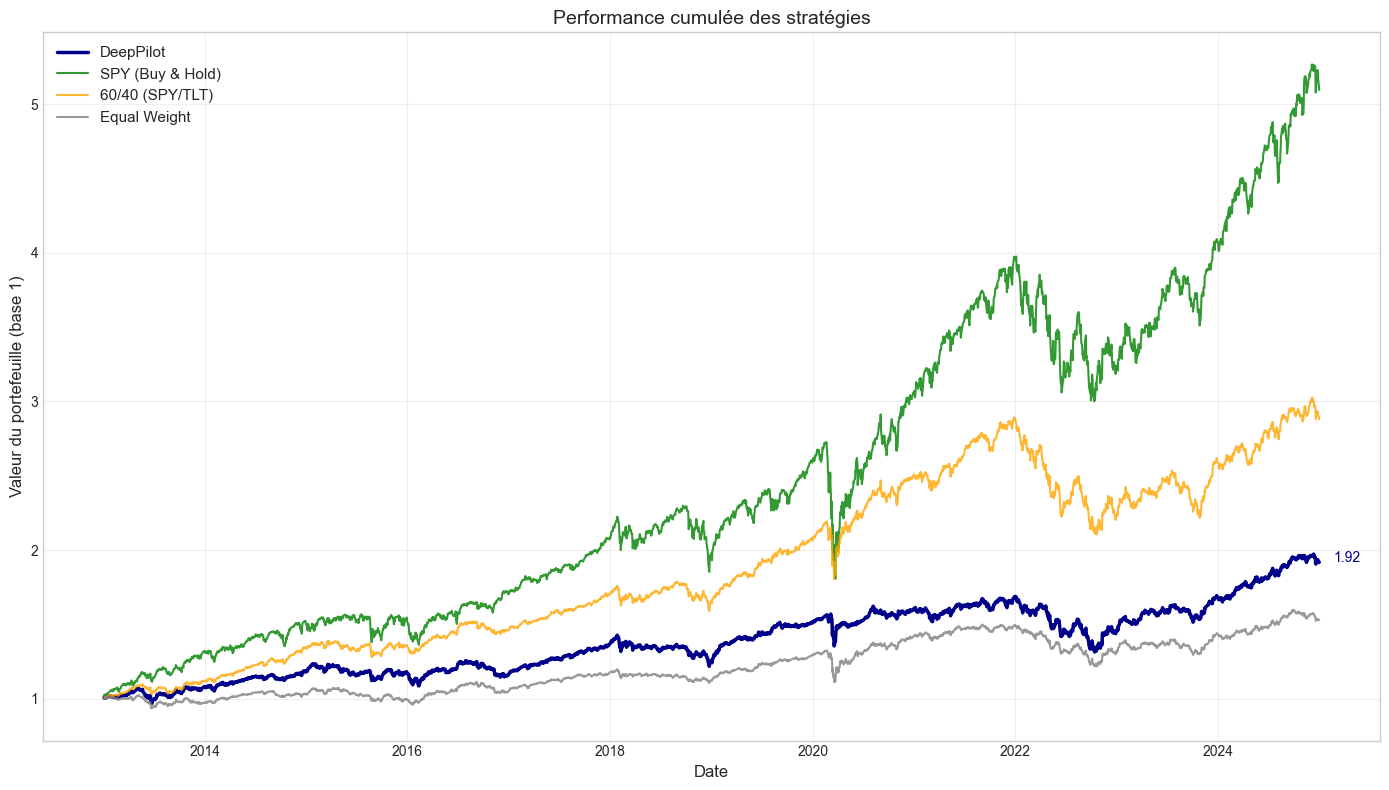

In [15]:
# Graphique des performances cumulées
fig, ax = plt.subplots(figsize=(14, 8))

# DeepPilot en premier (plus épais)
ax.plot(deeppilot_cumret.index, deeppilot_cumret.values, 
        label='DeepPilot', linewidth=2.5, color='darkblue')

# Benchmarks
colors = ['green', 'orange', 'gray']
for (name, cumret), color in zip(benchmark_cumret.items(), colors):
    ax.plot(cumret.index, cumret.values, label=name, linewidth=1.5, color=color, alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Valeur du portefeuille (base 1)', fontsize=12)
ax.set_title('Performance cumulée des stratégies', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Ajouter annotation valeur finale
final_date = deeppilot_cumret.index[-1]
ax.annotate(f'{deeppilot_cumret.iloc[-1]:.2f}', 
            xy=(final_date, deeppilot_cumret.iloc[-1]),
            xytext=(10, 0), textcoords='offset points',
            fontsize=10, color='darkblue')

plt.tight_layout()
plt.show()

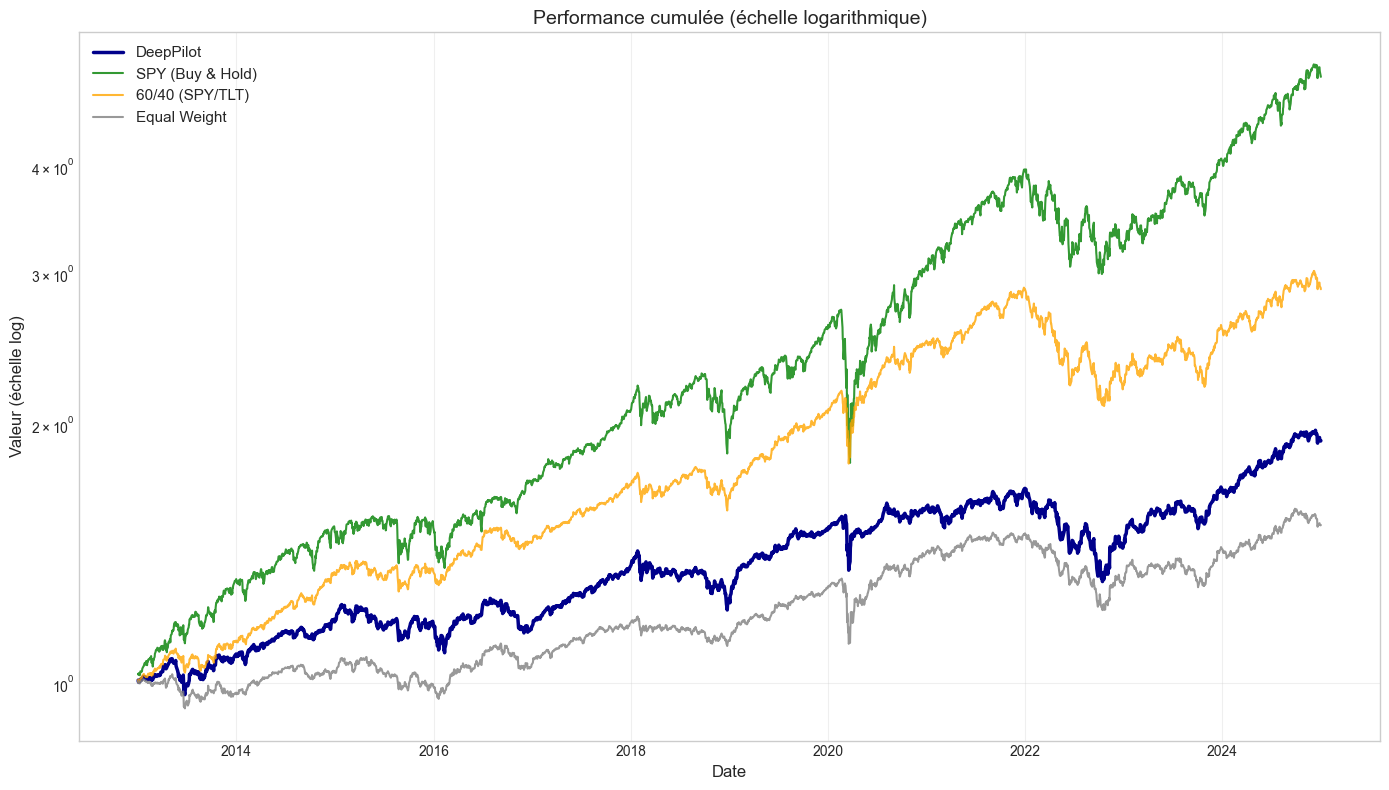

In [16]:
# Graphique en échelle log
fig, ax = plt.subplots(figsize=(14, 8))

ax.semilogy(deeppilot_cumret.index, deeppilot_cumret.values, 
            label='DeepPilot', linewidth=2.5, color='darkblue')

for (name, cumret), color in zip(benchmark_cumret.items(), colors):
    ax.semilogy(cumret.index, cumret.values, label=name, linewidth=1.5, color=color, alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Valeur (échelle log)', fontsize=12)
ax.set_title('Performance cumulée (échelle logarithmique)', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Drawdowns

In [17]:
# Calculer les drawdowns
deeppilot_dd = calculate_drawdown(deeppilot_cumret)

benchmark_dd = {}
for name, cumret in benchmark_cumret.items():
    benchmark_dd[name] = calculate_drawdown(cumret)

print(f"Max Drawdown DeepPilot : {deeppilot_dd.min()*100:.1f}%")
for name, dd in benchmark_dd.items():
    print(f"Max Drawdown {name} : {dd.min()*100:.1f}%")

Max Drawdown DeepPilot : -22.1%
Max Drawdown SPY (Buy & Hold) : -33.7%
Max Drawdown 60/40 (SPY/TLT) : -27.2%
Max Drawdown Equal Weight : -18.8%


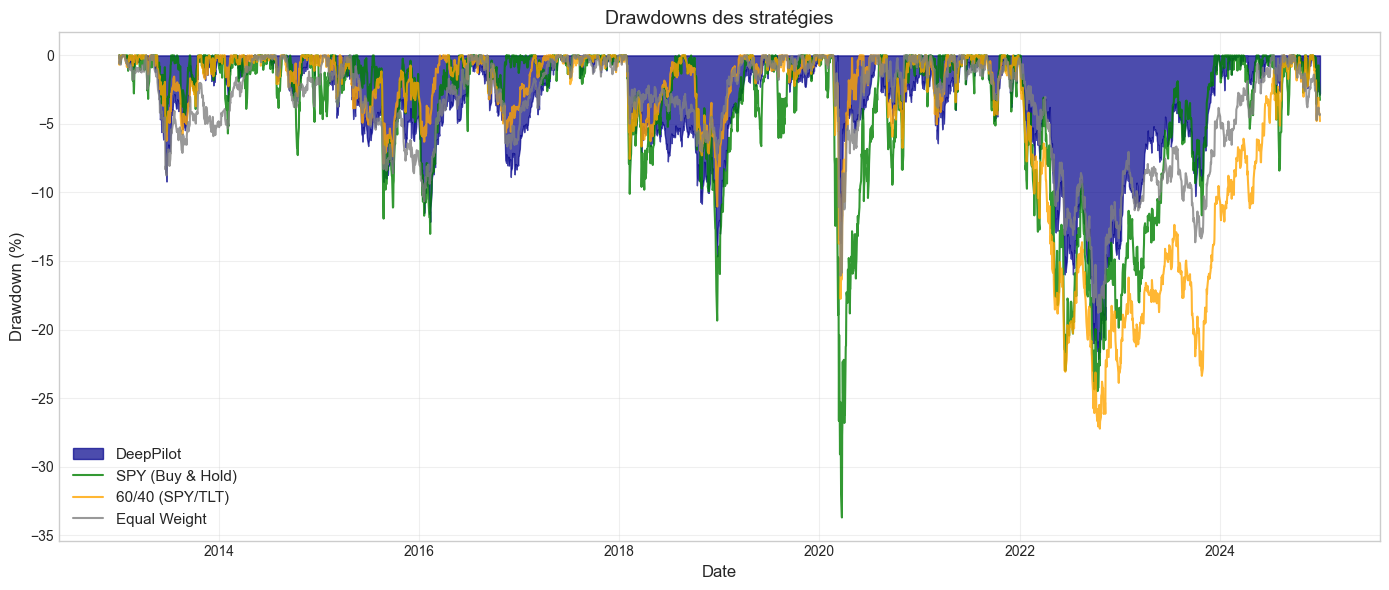

In [18]:
# Graphique des drawdowns
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(deeppilot_dd.index, 0, deeppilot_dd.values * 100, 
                label='DeepPilot', alpha=0.7, color='darkblue')

for (name, dd), color in zip(benchmark_dd.items(), colors):
    ax.plot(dd.index, dd.values * 100, label=name, linewidth=1.5, color=color, alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.set_title('Drawdowns des stratégies', fontsize=14)
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Analyse des allocations DeepPilot

In [19]:
# Historique des poids
weights_history = result.weights_history

if len(weights_history) > 0:
    print(f"Nombre de rebalancements : {len(weights_history)}")
    print(f"\nDernière allocation :")
    last_weights = weights_history.iloc[-1]
    for ticker in ETF_TICKERS:
        if ticker in last_weights:
            print(f"  {ticker}: {last_weights[ticker]*100:.1f}%")

Nombre de rebalancements : 144

Dernière allocation :
  SPY: 25.0%
  EFA: 5.0%
  EEM: 5.0%
  TLT: 5.0%
  HYG: 20.9%
  GLD: 24.7%
  VNQ: 9.3%
  SH: 5.0%


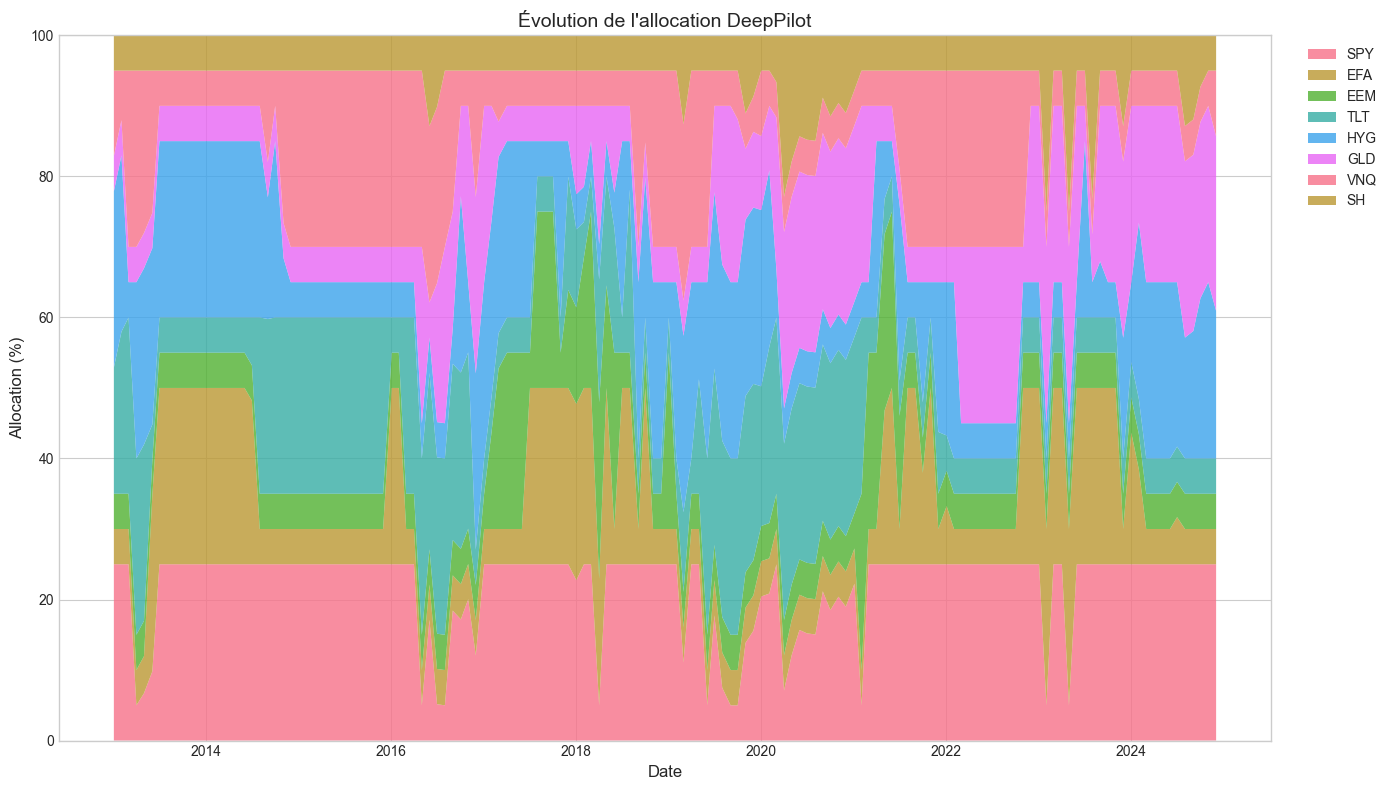

In [20]:
# Évolution des poids dans le temps
if len(weights_history) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Stacked area chart
    weight_cols = [col for col in weights_history.columns if col in ETF_TICKERS]
    weights_plot = weights_history[weight_cols].fillna(0)
    
    ax.stackplot(weights_plot.index, weights_plot.T * 100, labels=weight_cols, alpha=0.8)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Allocation (%)', fontsize=12)
    ax.set_title('Évolution de l\'allocation DeepPilot', fontsize=14)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

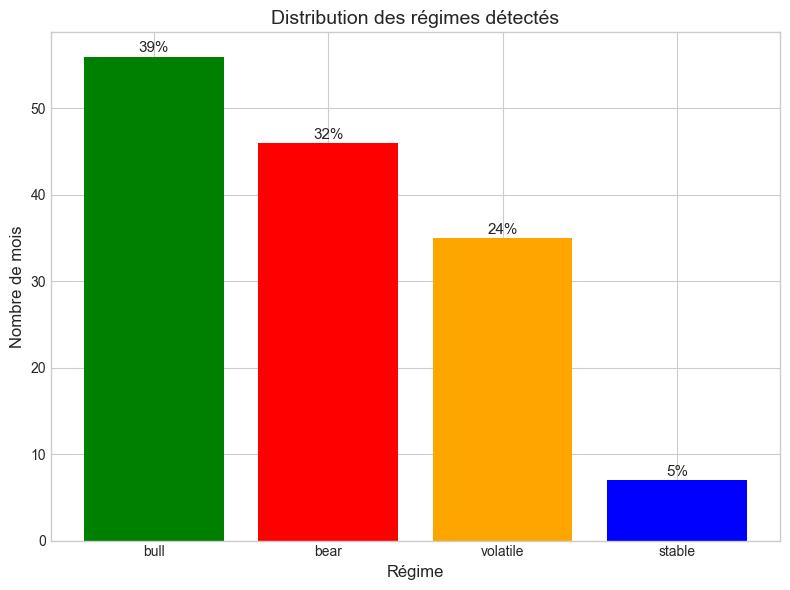

In [21]:
# Distribution des régimes pendant le backtest
if 'regime' in weights_history.columns:
    regime_dist = weights_history['regime'].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    regime_names = [REGIME_NAMES.get(i, f'Regime {i}') for i in regime_dist.index]
    colors = ['green', 'red', 'orange', 'blue']
    
    ax.bar(regime_names, regime_dist.values, color=[colors[i] for i in regime_dist.index])
    ax.set_xlabel('Régime', fontsize=12)
    ax.set_ylabel('Nombre de mois', fontsize=12)
    ax.set_title('Distribution des régimes détectés', fontsize=14)
    
    # Ajouter pourcentages
    total = regime_dist.sum()
    for i, (name, count) in enumerate(zip(regime_names, regime_dist.values)):
        ax.text(i, count + 0.5, f'{count/total*100:.0f}%', ha='center', fontsize=11)
    
    plt.tight_layout()
    plt.show()

## 8. Analyse des coûts de transaction

In [22]:
# Historique des trades
trades = result.trades_history

if trades:
    trades_df = pd.DataFrame(trades)
    
    total_turnover = trades_df['turnover'].sum()
    total_cost = trades_df['cost'].sum()
    avg_turnover = trades_df['turnover'].mean()
    
    print("Statistiques des transactions :")
    print(f"  Nombre de rebalancements : {len(trades_df)}")
    print(f"  Turnover total : {total_turnover*100:.1f}%")
    print(f"  Turnover moyen par rebalancement : {avg_turnover*100:.2f}%")
    print(f"  Coût total des transactions : {total_cost*100:.3f}%")

Statistiques des transactions :
  Nombre de rebalancements : 144
  Turnover total : 1392.5%
  Turnover moyen par rebalancement : 9.67%
  Coût total des transactions : 1.392%


## 9. Performance par année

In [23]:
# Calculer les returns annuels
def annual_returns(returns):
    return returns.groupby(returns.index.year).apply(lambda x: (1 + x).prod() - 1)

deeppilot_annual = annual_returns(result.returns) * 100

annual_comparison = pd.DataFrame({'DeepPilot': deeppilot_annual})

for name in benchmark_returns.columns:
    aligned = benchmark_returns[name].loc[result.returns.index]
    annual_comparison[name] = annual_returns(aligned) * 100

print("\nReturns annuels (%) :")
annual_comparison.round(1)


Returns annuels (%) :


,DeepPilot,SPY (Buy & Hold),60/40 (SPY/TLT),Equal Weight
date,,,,
2013,8.2,32.3,12.2,-2.4
2014,9.0,13.5,19.3,5.5
2015,-0.6,1.2,0.8,-3.6
2016,-0.7,12.0,8.1,6.1
2017,17.4,21.7,16.8,11.7
2018,-8.1,-4.6,-2.9,-4.4
2019,20.2,31.2,24.7,15.0
2020,6.5,18.3,21.5,10.3
2021,5.0,28.7,14.8,5.0


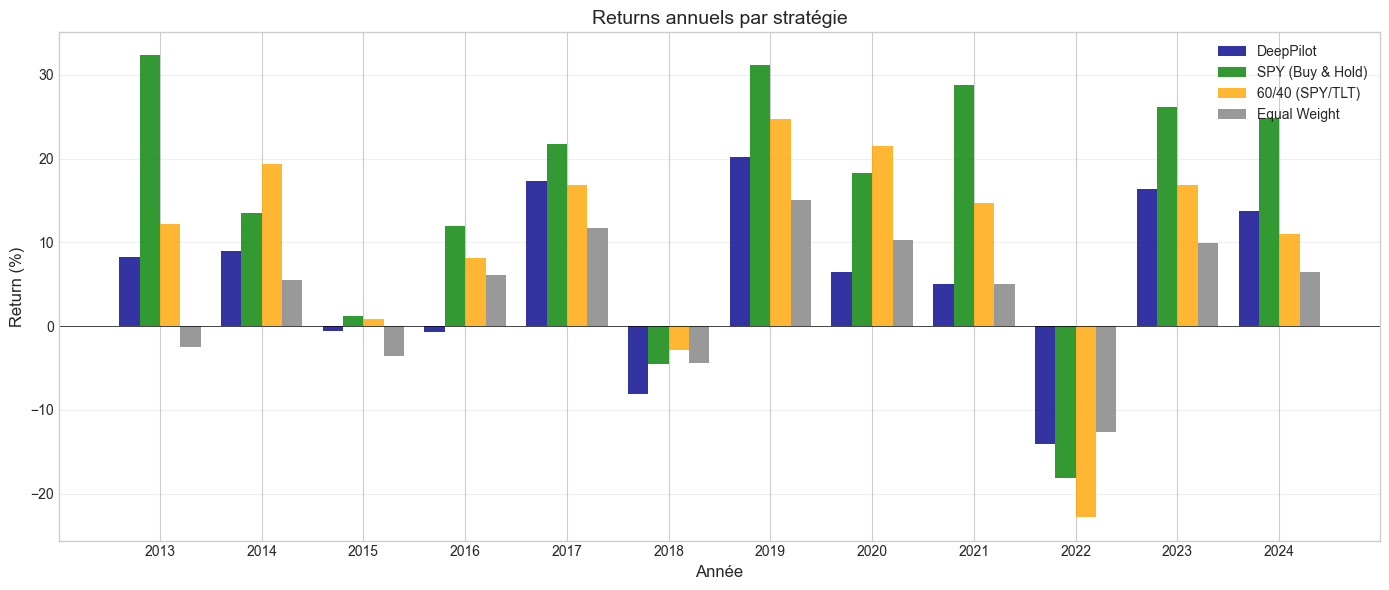

In [24]:
# Graphique des returns annuels
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(annual_comparison))
width = 0.2

colors_annual = ['darkblue', 'green', 'orange', 'gray']
for i, col in enumerate(annual_comparison.columns):
    ax.bar(x + i*width, annual_comparison[col], width, label=col, color=colors_annual[i], alpha=0.8)

ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Return (%)', fontsize=12)
ax.set_title('Returns annuels par stratégie', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(annual_comparison.index)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [25]:
# Années où DeepPilot bat les benchmarks
print("\nAnnées où DeepPilot surperforme :")
for year in annual_comparison.index:
    dp_ret = annual_comparison.loc[year, 'DeepPilot']
    spy_ret = annual_comparison.loc[year, 'SPY (Buy & Hold)']
    
    if dp_ret > spy_ret:
        diff = dp_ret - spy_ret
        print(f"  {year}: DeepPilot {dp_ret:+.1f}% vs SPY {spy_ret:+.1f}% (surperf: {diff:+.1f}%)")
    else:
        diff = dp_ret - spy_ret
        print(f"  {year}: DeepPilot {dp_ret:+.1f}% vs SPY {spy_ret:+.1f}% (underperf: {diff:+.1f}%)")


Années où DeepPilot surperforme :
  2013: DeepPilot +8.2% vs SPY +32.3% (underperf: -24.1%)
  2014: DeepPilot +9.0% vs SPY +13.5% (underperf: -4.5%)
  2015: DeepPilot -0.6% vs SPY +1.2% (underperf: -1.9%)
  2016: DeepPilot -0.7% vs SPY +12.0% (underperf: -12.7%)
  2017: DeepPilot +17.4% vs SPY +21.7% (underperf: -4.3%)
  2018: DeepPilot -8.1% vs SPY -4.6% (underperf: -3.5%)
  2019: DeepPilot +20.2% vs SPY +31.2% (underperf: -11.0%)
  2020: DeepPilot +6.5% vs SPY +18.3% (underperf: -11.8%)
  2021: DeepPilot +5.0% vs SPY +28.7% (underperf: -23.7%)
  2022: DeepPilot -14.1% vs SPY -18.2% (surperf: +4.1%)
  2023: DeepPilot +16.4% vs SPY +26.2% (underperf: -9.8%)
  2024: DeepPilot +13.7% vs SPY +24.9% (underperf: -11.2%)


## 10. Conclusion

In [26]:
# Résumé final
print("\n" + "="*70)
print("RÉSUMÉ FINAL DU BACKTEST")
print("="*70)

print(f"\nPériode : {START_DATE} à {END_DATE}")
print(f"Durée : {result.metrics.get('n_years', 'N/A')} ans")

print("\n" + "-"*70)
print("MÉTRIQUES COMPARATIVES")
print("-"*70)

print(comparison[['cagr_pct', 'volatility_pct', 'sharpe_ratio', 'max_drawdown_pct']].to_string())

print("\n" + "-"*70)
print("CONCLUSION")
print("-"*70)

# Déterminer si DeepPilot bat les benchmarks
dp_sharpe = comparison.loc['DeepPilot', 'sharpe_ratio']
spy_sharpe = comparison.loc['SPY (Buy & Hold)', 'sharpe_ratio'] if 'SPY (Buy & Hold)' in comparison.index else 0

if dp_sharpe > spy_sharpe:
    verdict = "DeepPilot SURPERFORME le benchmark SPY"
else:
    verdict = "DeepPilot SOUS-PERFORME le benchmark SPY"

print(f"\n{verdict}")
print(f"\nSharpe DeepPilot : {dp_sharpe:.3f}")
print(f"Sharpe SPY : {spy_sharpe:.3f}")

print("""\n
Points clés :
- DeepPilot combine détection de régime (HMM) + prédiction (RF) + optimisation (Markowitz)
- Rebalancement mensuel avec frais de 0.1% par trade inclus
- Contraintes strictes : 5% min / 25% max par ETF
- Le modèle s'adapte aux conditions de marché (bear, bull, volatile, stable)

Limitations :
- Performance passée ne garantit pas les résultats futurs
- Sensible aux périodes de crise non vues à l'entraînement
- Frais réels peuvent varier selon le courtier
""")
print("-"*70)


RÉSUMÉ FINAL DU BACKTEST

Période : 2013-01-01 à 2024-12-31
Durée : 11.98 ans

----------------------------------------------------------------------
MÉTRIQUES COMPARATIVES
----------------------------------------------------------------------
                  cagr_pct  volatility_pct  sharpe_ratio  max_drawdown_pct
strategy                                                                  
DeepPilot             5.59            8.95         0.289            -22.14
SPY (Buy & Hold)     14.55           16.71         0.691            -33.72
60/40 (SPY/TLT)       9.23           10.46         0.595            -27.24
Equal Weight          3.61            7.75         0.079            -18.78

----------------------------------------------------------------------
CONCLUSION
----------------------------------------------------------------------

DeepPilot SOUS-PERFORME le benchmark SPY

Sharpe DeepPilot : 0.289
Sharpe SPY : 0.691


Points clés :
- DeepPilot combine détection de régime (HMM) + 

In [27]:
# Sauvegarder les résultats
comparison.to_csv('../data/processed/strategy_comparison.csv')
annual_comparison.to_csv('../data/processed/annual_returns_comparison.csv')

if len(weights_history) > 0:
    weights_history.to_csv('../data/processed/deeppilot_weights_history.csv')

print("Résultats sauvegardés dans data/processed/")

Résultats sauvegardés dans data/processed/
